<h1 style="text-align: center;">Assessment 2 Part A: PRML Project (Stage 2/3)</h1>
<h2 style="text-align: center;">Pattern Recognition and Machine Learning</h2> 
<h3 style="text-align: center;">By Ruhan Shafi | u3284342</h3>

PLEASE DO NOT CLICK "Run All" if there is a folder called "HAM10000_images", as it will cause errors, ensure that all files apart from this notebook/`README.md` are removed prior to running the download commands

## Importing Libraries

In [ ]:
import pandas as pd
import tensorflow as tf
import os
import shutil
import zipfile
import glob
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

2025-09-28 08:55:32.576333: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-28 08:55:32.980604: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-28 08:55:34.690738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Downloading the Dataset via Kaggle CLI
Please ensure that your Kaggle CLI environment is properly configurated prior to running this command. Please check Kaggle API documentation to find out to configure the Kaggle CLI for your enviroment. Once it has been properly configured, uncomment the second line and run this command. (This has been commented so prevent accidental downloads as this takes up allocated API useage and to save on time and storage)

In [9]:
#!/bin/bash
#!kaggle datasets download kmader/skin-cancer-mnist-ham10000

## Extracting the Dataset + Getting everything in order

In [ ]:
# Not needed if you have already unzipped the file
base_dir = os.getcwd()
zip_path = os.path.join(base_dir, "skin-cancer-mnist-ham10000.zip")

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_dir)

# Output unified folder
img_dir = os.path.join(base_dir, "HAM10000_images")
os.makedirs(img_dir, exist_ok=True)

# Find all part folders (case-insensitive)
part_folders = glob.glob(os.path.join(base_dir, "*part*"))

# Move images into HAM10000_images
for folder in part_folders:
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            src = os.path.join(folder, file)
            dst = os.path.join(img_dir, file)
            shutil.move(src, dst)
        print(f"✅ Moved images from {os.path.basename(folder)}")
        shutil.rmtree(folder)  # delete folder after moving

print("✅ All images unified in:", img_dir)
print("Number of images:", len(os.listdir(img_dir)))


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Load metadata
# -------------------------
metadata = pd.read_csv("HAM10000_metadata.csv")

# -------------------------
# Class distribution
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x="dx", data=metadata, order=metadata["dx"].value_counts().index, palette="Set2")
plt.title("Class Distribution of Lesions")
plt.xlabel("Diagnosis (dx)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Age distribution per class
# -------------------------
plt.figure(figsize=(10,6))
sns.boxplot(x="dx", y="age", data=metadata, palette="Set3")
plt.title("Age Distribution by Diagnosis")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Sex distribution per class
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x="dx", hue="sex", data=metadata, palette="pastel")
plt.title("Sex Distribution Across Classes")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Localization distribution
# -------------------------
plt.figure(figsize=(10,6))
sns.countplot(x="localization", hue="dx", data=metadata, order=metadata["localization"].value_counts().index)
plt.title("Lesion Localization by Diagnosis")
plt.xticks(rotation=90)
plt.show()

# -------------------------
# Correlation heatmap (numeric features only)
# -------------------------
numeric_features = metadata[["age"]].copy()
numeric_features["dx_encoded"] = metadata["dx"].astype("category").cat.codes  # encode dx as numbers

corr = numeric_features.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Age vs Diagnosis)")
plt.show()


## Spilting the dataset

In [ ]:
# -------------------------
# Paths (everything in current folder)
# -------------------------
base_dir = os.getcwd()
img_dir = os.path.join(base_dir, "HAM10000_images")
metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")

# Output folders
train_dir = os.path.join(base_dir, "train_images")
test_dir = os.path.join(base_dir, "test_images")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# -------------------------
# Load metadata
# -------------------------
df = pd.read_csv(metadata_path)

print("✅ Metadata loaded.")
print("Number of rows:", len(df))
print("Unique classes:", df["dx"].unique())

# -------------------------
# Train/test split (80/20 stratified on dx)
# -------------------------
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["dx"],
    random_state=42
)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Save metadata CSVs
train_metadata_path = os.path.join(base_dir, "train_metadata.csv")
test_metadata_path = os.path.join(base_dir, "test_metadata.csv")

train_df.to_csv(train_metadata_path, index=False)
test_df.to_csv(test_metadata_path, index=False)

print(f"✅ Saved: train_metadata.csv")
print(f"✅ Saved: test_metadata.csv")

# -------------------------
# Copy images into split folders
# -------------------------
def copy_images(df, target_dir):
    copied, missing = 0, []
    for img_id in df["image_id"]:
        src = os.path.join(img_dir, img_id + ".jpg")
        dst = os.path.join(target_dir, img_id + ".jpg")
        if os.path.exists(src):
            shutil.copy(src, dst)
            copied += 1
        else:
            missing.append(img_id)
    print(f"📂 Copied {copied} images → {os.path.basename(target_dir)}")
    if missing:
        print(f"⚠️ Missing {len(missing)} images. Example: {missing[:10]}")

copy_images(train_df, train_dir)
copy_images(test_df, test_dir)

print("🎉 Dataset split complete.")


✅ Metadata loaded.
Number of rows: 10015
Unique classes: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
Train size: 8012, Test size: 2003
✅ Saved: train_metadata.csv
✅ Saved: test_metadata.csv
📂 Copied 8012 images → train_images
📂 Copied 2003 images → test_images
🎉 Dataset split complete.


## Moves and Sorts images into folders by `dx` type

In [2]:


# -------------------------
# Paths - Variables are redecaleed here so you don't have to run the unzip cell which unzips regardless of if the file was previously unzipped
# -------------------------
base_dir = os.getcwd()
train_dir = os.path.join(base_dir, "train_images")
test_dir = os.path.join(base_dir, "test_images")
train_csv = os.path.join(base_dir, "train_metadata.csv")
test_csv = os.path.join(base_dir, "test_metadata.csv")

# -------------------------
# Load metadata
# -------------------------
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# -------------------------
# Function to reorganize images into class subfolders
# -------------------------
def reorganize_images(df, img_dir):
    """
    Moves images into class subfolders based on 'dx' column.
    """
    for _, row in df.iterrows():
        class_folder = os.path.join(img_dir, row['dx'])
        os.makedirs(class_folder, exist_ok=True)  # create class folder if missing
        src = os.path.join(img_dir, row['image_id'] + ".jpg")
        dst = os.path.join(class_folder, row['image_id'] + ".jpg")
        # Move image only if it is in the root of img_dir
        if os.path.exists(src):
            shutil.move(src, dst)

# Reorganize train and test images
reorganize_images(train_df, train_dir)
reorganize_images(test_df, test_dir)

print("✅ Images reorganized into class subfolders for TensorFlow.")



✅ Images reorganized into class subfolders for TensorFlow.


## Data Analysis Graph for Report

/tmp/ipykernel_4548/3598846031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="dx", data=metadata, order=metadata["dx"].value_counts().index, palette="Set2")


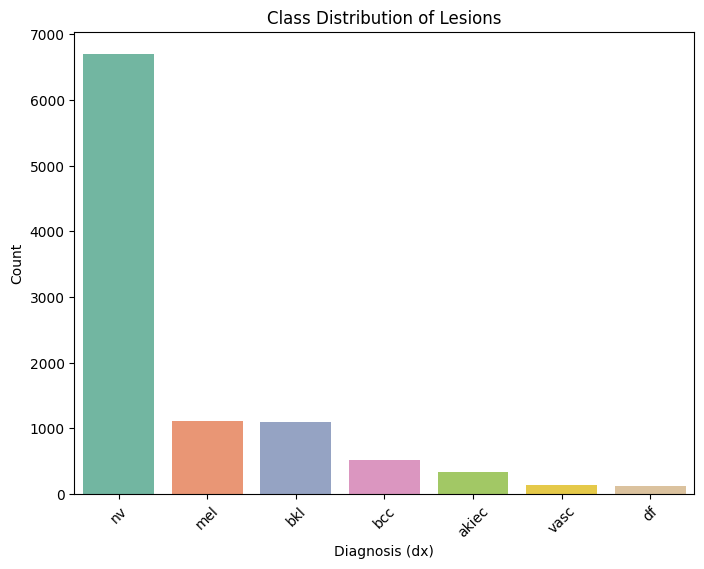

/tmp/ipykernel_4548/3598846031.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="dx", y="age", data=metadata, palette="Set3")


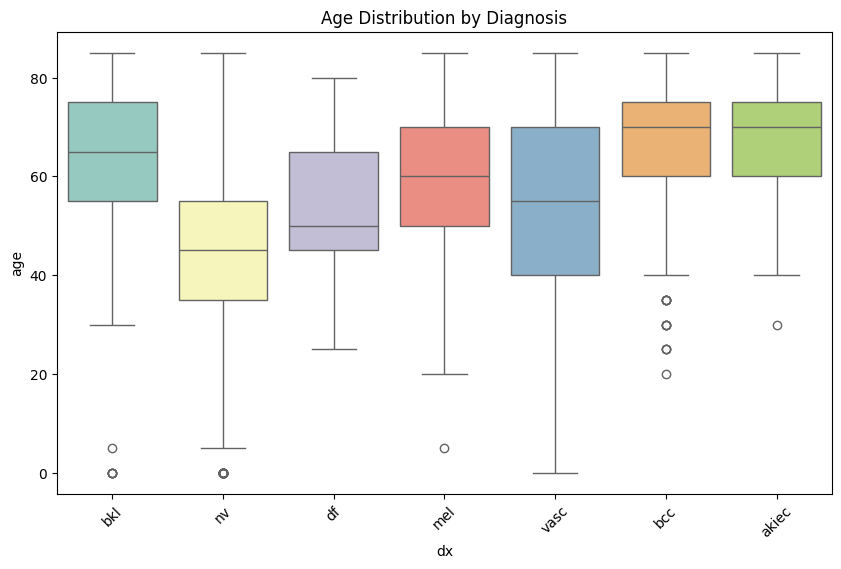

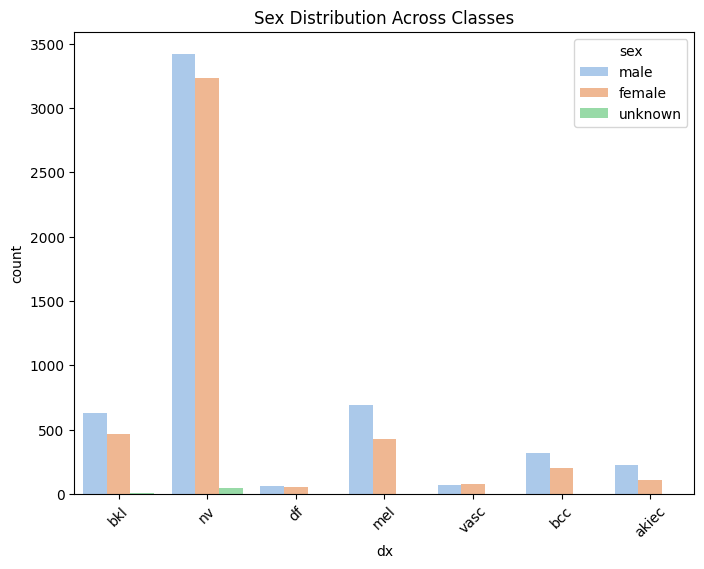

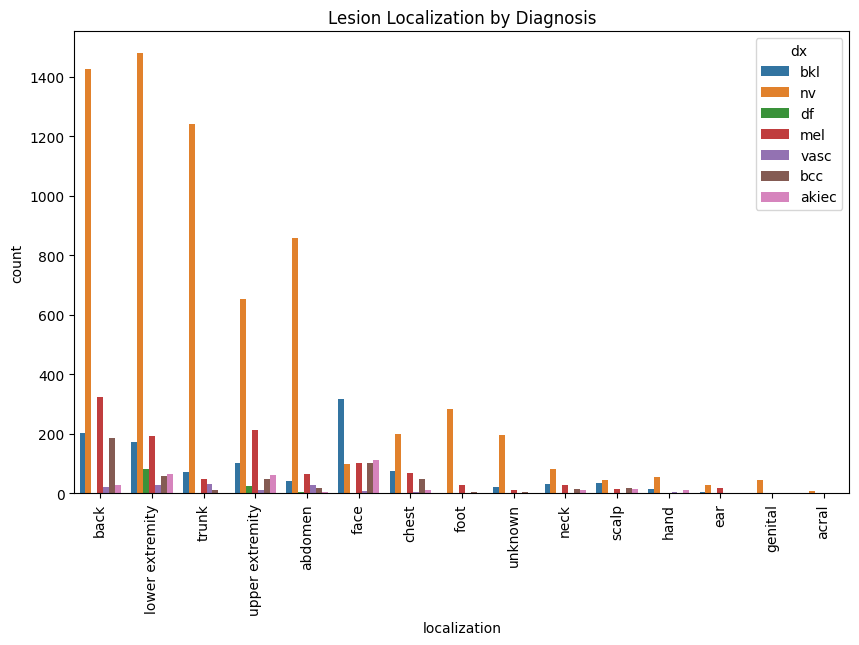

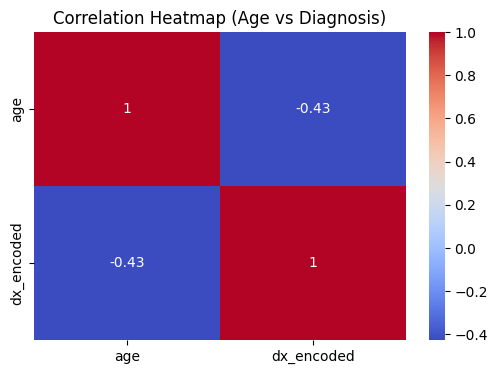

In [30]:

# -------------------------
# Load metadata
# -------------------------
metadata = pd.read_csv("HAM10000_metadata.csv")

# -------------------------
# Class distribution
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x="dx", data=metadata, order=metadata["dx"].value_counts().index, palette="Set2")
plt.title("Class Distribution of Lesions")
plt.xlabel("Diagnosis (dx)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Age distribution per class
# -------------------------
plt.figure(figsize=(10,6))
sns.boxplot(x="dx", y="age", data=metadata, palette="Set3")
plt.title("Age Distribution by Diagnosis")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Sex distribution per class
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x="dx", hue="sex", data=metadata, palette="pastel")
plt.title("Sex Distribution Across Classes")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Localization distribution
# -------------------------
plt.figure(figsize=(10,6))
sns.countplot(x="localization", hue="dx", data=metadata, order=metadata["localization"].value_counts().index)
plt.title("Lesion Localization by Diagnosis")
plt.xticks(rotation=90)
plt.show()

# -------------------------
# Correlation heatmap (numeric features only)
# -------------------------
numeric_features = metadata[["age"]].copy()
numeric_features["dx_encoded"] = metadata["dx"].astype("category").cat.codes  # encode dx as numbers

corr = numeric_features.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Age vs Diagnosis)")
plt.show()


## Import the data into both the Sci-Kit Learn Enviornment and Tensorflow Enviornment

RUN FROM HERE IF MARKING, YOU DO NOT NEED TO RUN PREVIOUS COMMAND AS I HAVE ATTACHED THE DATA

In [3]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32

# -------------------------
# Train dataset
# -------------------------
train_tensorflow = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",  # for multi-class classification
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

# -------------------------
# Test dataset
# -------------------------
test_tensorflow = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

print("✅ TensorFlow datasets ready")


Found 8012 files belonging to 7 classes.
Found 2003 files belonging to 7 classes.
✅ TensorFlow datasets ready


2025-09-28 08:55:40.505639: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Loading Data into Sci-Kit Learn

In [4]:


def create_sklearn_mapping(df, img_dir):
    X_paths = []
    y_labels = []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['dx'], row['image_id'] + ".jpg")
        X_paths.append(path)
        y_labels.append(row['dx'])
    return X_paths, y_labels

X_train_sklearn, y_train_sklearn = create_sklearn_mapping(train_df, train_dir)
X_test_sklearn, y_test_sklearn = create_sklearn_mapping(test_df, test_dir)

print(f"✅ Scikit-Learn mapping ready: {len(X_train_sklearn)} train, {len(X_test_sklearn)} test images")

# -------------------------
# Load Scikit-Learn images safely in chunks
# -------------------------
img_size = (64, 64)
chunk_size = 500

def load_images_sklearn(paths, labels, img_size=(64,64), chunk_size=500):
    X = []
    y = []
    total = len(paths)
    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)
        for i in range(start, end):
            img = cv2.imread(paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            X.append(img.flatten())
            y.append(labels[i])
    X = np.array(X)
    y = np.array(y)
    return X, y

X_train_sklearn_array, y_train_sklearn_array = load_images_sklearn(X_train_sklearn, y_train_sklearn, img_size, chunk_size)
X_test_sklearn_array, y_test_sklearn_array   = load_images_sklearn(X_test_sklearn, y_test_sklearn, img_size, chunk_size)

# Encode labels
le = LabelEncoder()
y_train_sklearn_enc = le.fit_transform(y_train_sklearn_array)
y_test_sklearn_enc  = le.transform(y_test_sklearn_array)

print(f"✅ Scikit-Learn: X_train: {X_train_sklearn_array.shape}, X_test: {X_test_sklearn_array.shape}")
print(f"✅ Example encoded labels: {np.unique(y_train_sklearn_enc)}")


✅ Scikit-Learn mapping ready: 8012 train, 2003 test images
✅ Scikit-Learn: X_train: (8012, 12288), X_test: (2003, 12288)
✅ Example encoded labels: [0 1 2 3 4 5 6]


# Visulizating the Data
Mostly here as a sanity check that the dataset has been loaded properly in both environments alongside their labels.

### Tensorflow 

2025-09-28 08:56:21.830505: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


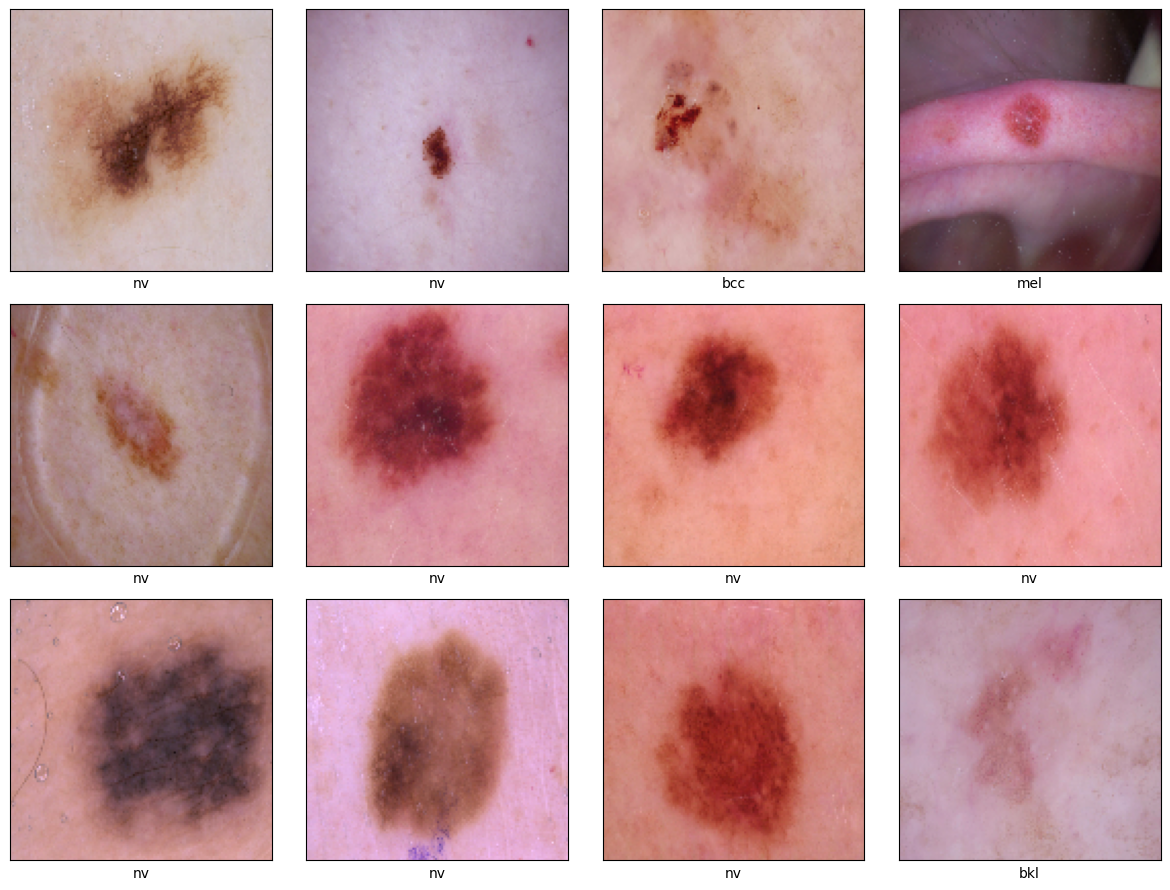

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Access class names from the TensorFlow dataset
class_names = train_tensorflow.class_names

# Take one batch from the TensorFlow dataset
for images, labels in train_tensorflow.take(1):
    images = images.numpy().astype(np.uint8)
    labels = labels.numpy()

# Sample 12 random images from this batch
indices = random.sample(range(images.shape[0]), 12)

fig, ax = plt.subplots(3, 4, figsize=(12, 9))
for i, axi in enumerate(ax.flat):
    axi.imshow(images[indices[i]])
    class_idx = np.argmax(labels[indices[i]])
    axi.set_xticks([])
    axi.set_yticks([])
    axi.set_xlabel(class_names[class_idx])
plt.tight_layout()
plt.show()


### Sci-Kit Learn

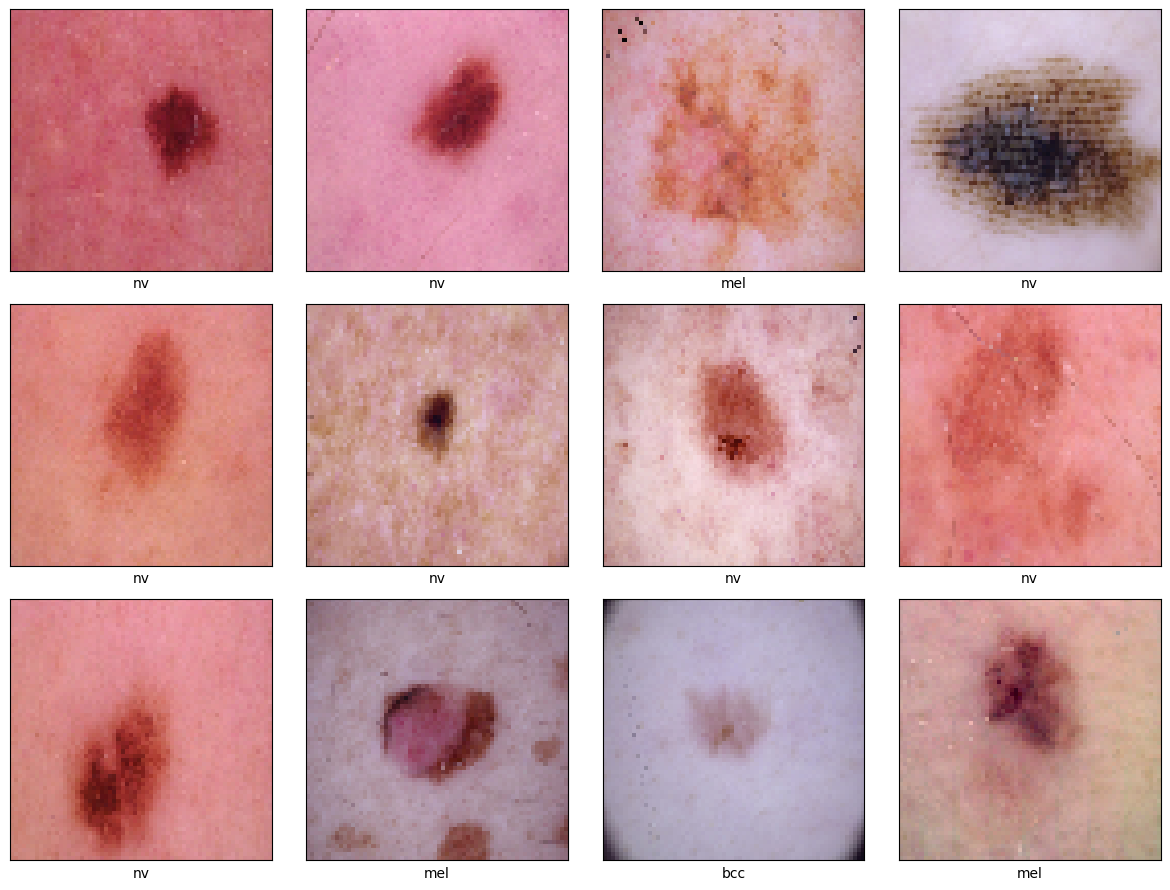

In [6]:
import matplotlib.pyplot as plt
import random

# Sample 12 random images from train set
indices = random.sample(range(X_train_sklearn_array.shape[0]), 12)

fig, ax = plt.subplots(3, 4, figsize=(12, 9))
for i, axi in enumerate(ax.flat):
    axi.imshow(X_train_sklearn_array[indices[i]].reshape(64, 64, 3).astype(np.uint8))
    axi.set_xticks([])
    axi.set_yticks([])
    axi.set_xlabel(y_train_sklearn_array[indices[i]])
plt.tight_layout()
plt.show()


# SVM using Scikit Learn

### Principal Component Analysis (PCA)
This section of code is responsible for apply the dimesnsionality reduction technique known as Principal Component Analysis (PCA). This is used to transfer a large set of features into a smaller set that (in therory) still contains most of the revleant information within the original data. This is achived by finding principal components within the dataset, refered to as axes that captures the maximum variance of the data. This is used to reduce the number of features wile minimizing information lose 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# -------------------------
# Dimensionality Reduction with PCA
# -------------------------
# Keep 95% variance
pca = PCA(n_components=0.95, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train_sklearn_array)
X_test_pca = pca.transform(X_test_sklearn_array)

print(f"✅ Original shape: {X_train_sklearn_array.shape}")
print(f"✅ Reduced shape (PCA): {X_train_pca.shape}")


✅ Original shape: (8012, 12288)
✅ Reduced shape (PCA): (8012, 185)


In [24]:
# -------------------------
# Define parameter grid
# -------------------------
param_grid = [
    {
        'C': [0.1, 1, 5, 10],
        'kernel': ['linear'],
        'class_weight': ['balanced']
    },
    {
        'C': [0.1, 1, 5, 10],
        'gamma': [0.0001, 0.001, 0.01, 0.1],
        'kernel': ['rbf'],
        'class_weight': ['balanced']
    }
]

# -------------------------
# Run Grid Search with cross-validation
# -------------------------
grid = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train_pca, y_train_sklearn_enc)

print("✅ Best parameters:", grid.best_params_)
print("✅ Best cross-validation accuracy:", grid.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ........C=0.1, class_weight=balanced, kernel=linear; total time=  28.8s
[CV] END ........C=0.1, class_weight=balanced, kernel=linear; total time=  29.0s
[CV] END ........C=0.1, class_weight=balanced, kernel=linear; total time=  29.9s
[CV] END C=0.1, class_weight=balanced, gamma=0.001, kernel=rbf; total time= 1.2min
[CV] END C=0.1, class_weight=balanced, gamma=0.0001, kernel=rbf; total time= 1.2min
[CV] END C=0.1, class_weight=balanced, gamma=0.0001, kernel=rbf; total time= 1.2min
[CV] END C=0.1, class_weight=balanced, gamma=0.0001, kernel=rbf; total time= 1.2min
[CV] END ..........C=1, class_weight=balanced, kernel=linear; total time= 1.6min
[CV] END ..........C=1, class_weight=balanced, kernel=linear; total time= 1.6min
[CV] END ..........C=1, class_weight=balanced, kernel=linear; total time= 1.7min
[CV] END C=0.1, class_weight=balanced, gamma=0.01, kernel=rbf; total time= 1.2min
[CV] END C=0.1, class_weight=balance


✅ Test Accuracy: 0.7164253619570644

Classification Report:
               precision    recall  f1-score   support

       akiec       0.55      0.09      0.16        65
         bcc       0.70      0.29      0.41       103
         bkl       0.64      0.30      0.41       220
          df       1.00      0.13      0.23        23
         mel       0.54      0.03      0.06       223
          nv       0.72      0.98      0.83      1341
        vasc       0.91      0.36      0.51        28

    accuracy                           0.72      2003
   macro avg       0.72      0.31      0.37      2003
weighted avg       0.69      0.72      0.64      2003



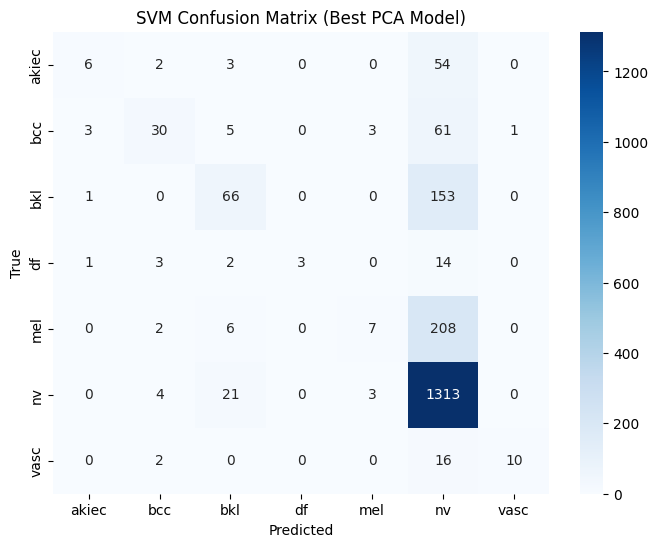

In [25]:
# -------------------------
# Evaluate on test set
# -------------------------
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_pca)

print("\n✅ Test Accuracy:", accuracy_score(y_test_sklearn_enc, y_pred))
print("\nClassification Report:\n", classification_report(y_test_sklearn_enc, y_pred, target_names=le.classes_))

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test_sklearn_enc, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix (Best PCA Model)")
plt.show()


### Decision Tree Classifier with PCA + Grid Search
Code adapted from tutorial.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# Define the model
dt_model = DecisionTreeClassifier(random_state=42)

# Define hyperparameters to tune
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(1, 10),   # search depth from 1 to 9
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run Grid Search with cross-validation
grid_search_dt = GridSearchCV(dt_model, param_grid=param_grid_dt, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train_pca, y_train_sklearn_enc)

# Output the best hyperparameters
print("Best Hyperparameters:", grid_search_dt.best_params_)

# Use the best estimator to make predictions
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_pca)

# Evaluate the model
print("Accuracy:", metrics.accuracy_score(y_test_sklearn_enc, y_pred_dt))
print("Precision:", metrics.precision_score(y_test_sklearn_enc, y_pred_dt, average='weighted'))
print("Recall:", metrics.recall_score(y_test_sklearn_enc, y_pred_dt, average='weighted'))
print("F1-score:", metrics.f1_score(y_test_sklearn_enc y_pred_dt, average='weighted'))


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.6784822765851223
Precision: 0.5954740731302105
Recall: 0.6784822765851223
F1-score: 0.5928174999419334


/home/ruhanshafi/Projects/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# CNN using Tensorflow

## Configuring the dataset from increased performance

This section of code is responsible for the application of the following two functions of the dataset. This is done to ensure that during the training process, when the datasets are fed into the model the I/O isn't blocked, this has the positive benefits of reducing system load and speeding up the training process exponentially.

The purpose of the `.cache()` function is to keep data loaded into the Tensorflow VM's memory after it's loaded of the disk. This is done in order to make the recall of the data far easier & faster. This is easily helpful during the evaluation process that occurs after each epoch. If the dataset is too large to fit into memory, then this method creates a performant on-disk cache, which is more efficient to read than many small files, this is akin to a swap partiation on linux, where addtional memory is storted tempoararly on the disk when memory is full.

The purpose of the `.prefetch()` function is to allow for the overlapping of data preprocessing and model execution while training. This inturn dramaticlly speeds up the training process.

Addtionally, the `.shuffle() `function randomly shuffles the data around in order to remove training bias since the data was previously ordered sequentially.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_tensorflow = train_tensorflow.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_tensorflow = test_tensorflow.cache().prefetch(buffer_size=AUTOTUNE)

## Standardizing the dataset

This section of code is responsible for scaling the RGB channel values for each pixel from `[0,255]` to `[0,1]`. This makes training the model easier since the matrix multiplication calucations returns far easier numbers to work with.

Dont run this more then once per instance

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_tensorflow.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))


0.0136852795 0.9628572


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(class_names)

# CNN model
model = models.Sequential([
    layers.InputLayer(input_shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)   #
])


/home/ruhanshafi/Projects/.venv/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [10]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,767 (8.09 MB)

 Trainable params: 2,121,767 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
epochs = 10
history = model.fit(
    train_tensorflow,
    validation_data=test_tensorflow,
    epochs=epochs
)


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 187ms/step - accuracy: 0.6669 - loss: 1.0108 - val_accuracy: 0.6755 - val_loss: 0.9075
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.6886 - loss: 0.8778 - val_accuracy: 0.6930 - val_loss: 0.8891
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 176ms/step - accuracy: 0.7057 - loss: 0.8132 - val_accuracy: 0.7094 - val_loss: 0.7975
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 182ms/step - accuracy: 0.7323 - loss: 0.7312 - val_accuracy: 0.7194 - val_loss: 0.7799
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 183ms/step - accuracy: 0.7521 - loss: 0.6676 - val_accuracy: 0.7269 - val_loss: 0.7587
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 180ms/step - accuracy: 0.7652 - loss: 0.6285 - val_accuracy: 0.7424 - val_loss: 0.7104
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 178ms/step - accuracy: 0.7817 - loss: 0.5821 - val_accuracy: 0.7464 - val_loss: 0.7315
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 180ms/step - accuracy: 0.8054 - loss: 0

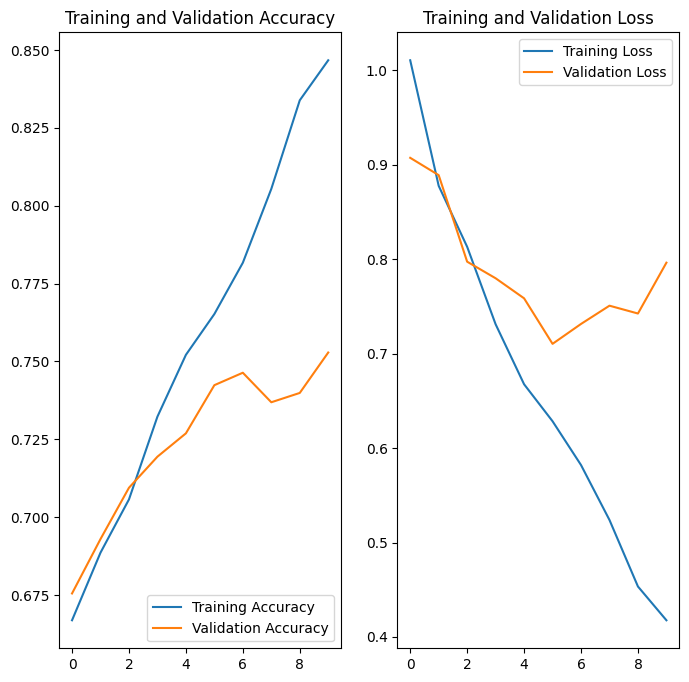

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [15]:
data_augmentation = tf.keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/home/ruhanshafi/Projects/.venv/lib/python3.13/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


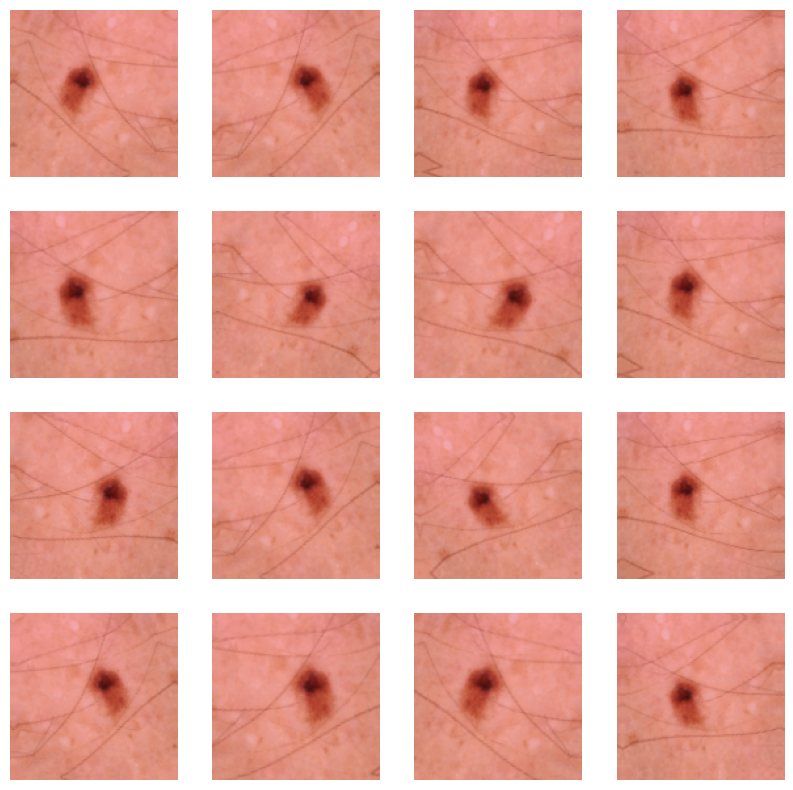

In [16]:


plt.figure(figsize=(10, 10))
for images, _ in train_tensorflow.take(1):
  for i in range(16):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")



In [17]:
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),  # normalize after augmentation
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)  # no softmax → use from_logits=True
])

In [18]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,767 (8.09 MB)

 Trainable params: 2,121,767 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
epochs = 15
history = model.fit(
  train_tensorflow,
  validation_data=test_tensorflow,
  epochs=epochs
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 187ms/step - accuracy: 0.6685 - loss: 0.9913 - val_accuracy: 0.6890 - val_loss: 0.8682
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.6856 - loss: 0.8362 - val_accuracy: 0.6915 - val_loss: 0.8655
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.7041 - loss: 0.7962 - val_accuracy: 0.6680 - val_loss: 0.8741
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.7192 - loss: 0.7552 - val_accuracy: 0.7269 - val_loss: 0.7666
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.7282 - loss: 0.7244 - val_accuracy: 0.7214 - val_loss: 0.7885
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 185ms/step - accuracy: 0.7361 - loss: 0.7148 - val_accuracy: 0.7159 - val_loss: 0.7640
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 185ms/step - accuracy: 0.7384 - loss: 0.6936 - val_accuracy: 0.7384 - val_loss: 0.7168
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 183ms/step - accuracy: 0.7461 - loss: 0

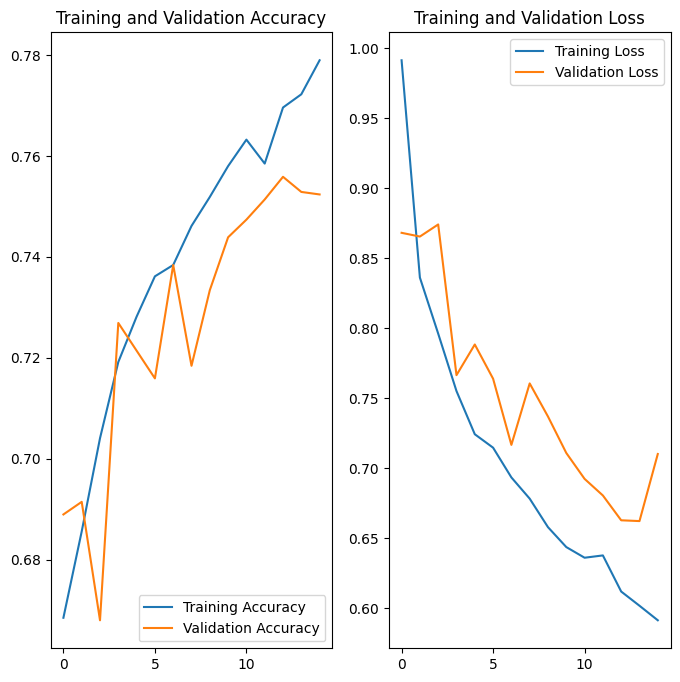

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
